In [1]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean as cmo
import matplotlib
import matplotlib.path as mpath
import matplotlib.pyplot as plt
import momlevel as ml
import numpy as np
import seaborn as sns
import xarray as xr
import sectionate

import warnings

warnings.simplefilter(action="ignore", category=FutureWarning)

In [2]:
bgose_id = '041'

In [3]:
Names = [
    "Generic",
    "Larsen G",
    "Larsen F",
    "Larsen E",
    "Larsen D",
    "Larsen C",
    "Larsen B",
    "Wordie",
    "Wilkins",
    "Bach",
    "George VI",
    "Stange",
    "Ronne",
    "Ferrigno",
    "Venable",
    "Abbot",
    "Cosgrove",
    "Pine Island",
    "Thwaites",
    "Crosson",
    "Dotson",
    "Getz",
    "Land",
    "Nickerson",
    "Sulzberger",
    "Swinburne",
    "Withrow",
    "Ross West",
    "Ross East",
    "Drygalski",
    "Nansen",
    "Aviator",
    "Mariner",
    "Lillie",
    "Rennick",
    "Cook",
    "Ninnis",
    "Mertz",
    "Dibble",
    "Holmes",
    "Moscow University",
    "Totten",
    "Vincennes",
    "Conger_Glenzer",
    "Tracy_Tremenchus",
    "Shackleton",
    "West",
    "Publications",
    "Amery",
    "Wilma_Robert_Downer",
    "Edward VIII",
    "Rayner_Thyer",
    "Shirase",
    "Prince Harald",
    "Baudouin",
    "Borchgrevink",
    "Lazarev",
    "Nivl",
    "Vigrid",
    "Fimbul",
    "Jelbart",
    "Atka",
    "Ekstrom",
    "Quar",
    "Riiser-Larsen",
    "Brunt_Stancomb",
    "Filchner",
]

In [4]:
ds_ice_id = xr.open_dataset(f"/work/Katherine.Turner/BGOSE/data_i000_SO65/iceshelves_bgose6_extended.nc")
ds_T = xr.open_dataset(f"/work/Katherine.Turner/BGOSE/data_i{bgose_id}_glob/Theta_bgoseI{bgose_id}s65_2013to2026_monthly.nc")
ds_S = xr.open_dataset(f"/work/Katherine.Turner/BGOSE/data_i{bgose_id}_glob/Salt_bgoseI{bgose_id}s65_2013to2026_monthly.nc")

In [5]:
idx_shelf = (ds_S.Depth <= 1000) & (ds_S.Depth > 0)

In [6]:
idx_AP = ds_ice_id.shelf_mask.isin(np.arange(1, 12)) & idx_shelf
idx_WA = ds_ice_id.shelf_mask.isin(np.arange(13, 27)) & idx_shelf
idx_RS = ds_ice_id.shelf_mask.isin(np.arange(27, 29)) & idx_shelf
idx_EA = ds_ice_id.shelf_mask.isin(np.arange(29, 66)) & idx_shelf
idx_RF = ds_ice_id.shelf_mask.isin([12, 66]) & idx_shelf
idx_other = (ds_ice_id.shelf_mask == 0) & idx_shelf

## Finding under-shelf temperatures and salinities

In [6]:
Theta_AP = ds_T.THETA.where(idx_AP)
Theta_WA = ds_T.THETA.where(idx_WA)
Theta_EA = ds_T.THETA.where(idx_EA)
Theta_RF = ds_T.THETA.where(idx_RF)

In [7]:
Salt_AP = ds_S.SALT.where(idx_AP)
Salt_WA = ds_S.SALT.where(idx_WA)
Salt_EA = ds_S.SALT.where(idx_EA)
Salt_RF = ds_S.SALT.where(idx_RF)

In [7]:
T_WA_detrended = ml.trend.linear_detrend(Theta_WA[24:,:,:,:])
WA_model, resid = ml.trend.seasonal_model(T_WA_detrended, return_model=True)
WA_model2 = WA_model.groupby(WA_model.time.dt.month).mean()

T_EA_detrended = ml.trend.linear_detrend(Theta_EA[24:,:,:,:])
EA_model, resid = ml.trend.seasonal_model(T_EA_detrended, return_model=True)
EA_model2 = EA_model.groupby(EA_model.time.dt.month).mean()

T_RF_detrended = ml.trend.linear_detrend(Theta_RF[24:,:,:,:])
RF_model, resid = ml.trend.seasonal_model(T_RF_detrended, return_model=True)
RF_model2 = RF_model.groupby(RF_model.time.dt.month).mean()

/nbhome/Katherine.Turner/miniconda3/envs/py310/lib/python3.10/site-packages/xarray/core/accessor_dt.py:72: FutureWarning: Index.ravel returning ndarray is deprecated; in a future version this will return a view on self.
  values_as_series = pd.Series(values.ravel(), copy=False)
/nbhome/Katherine.Turner/miniconda3/envs/py310/lib/python3.10/site-packages/xarray/core/accessor_dt.py:72: FutureWarning: Index.ravel returning ndarray is deprecated; in a future version this will return a view on self.
  values_as_series = pd.Series(values.ravel(), copy=False)
/nbhome/Katherine.Turner/miniconda3/envs/py310/lib/python3.10/site-packages/xarray/core/accessor_dt.py:72: FutureWarning: Index.ravel returning ndarray is deprecated; in a future version this will return a view on self.
  values_as_series = pd.Series(values.ravel(), copy=False)
/nbhome/Katherine.Turner/miniconda3/envs/py310/lib/python3.10/site-packages/xarray/core/accessor_dt.py:72: FutureWarning: Index.ravel returning ndarray is deprecat

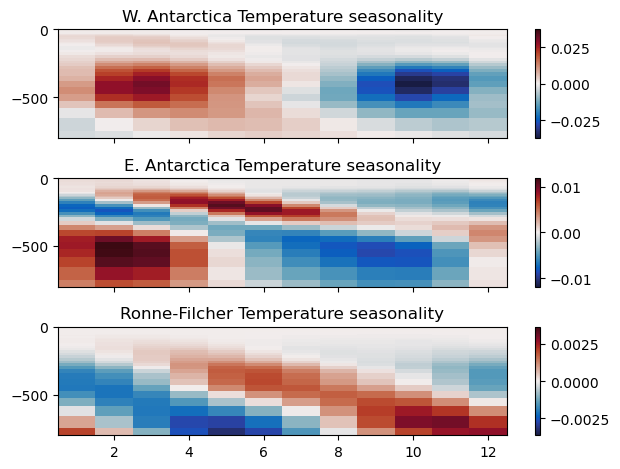

In [9]:
regions = ['W. Antarctica', 'E. Antarctica', 'Ronne-Filcher']

figs, axs = plt.subplots(nrows=3, ncols=1, sharex=True)

WA_model2.weighted(ds_T.rA).mean(dim=["YC", "XC"]).plot(ax=axs[0], cmap=cmo.cm.balance)
EA_model2.weighted(ds_T.rA).mean(dim=["YC", "XC"]).plot(ax=axs[1], cmap=cmo.cm.balance)
RF_model2.weighted(ds_T.rA).mean(dim=["YC", "XC"]).plot(ax=axs[2], cmap=cmo.cm.balance)

for i in range(3):
    axs[i].set_ylim([-800, 0])
    axs[i].set_title(regions[i] + ' Temperature seasonality')
    axs[i].set_ylabel('')
    axs[i].set_xlabel('')
    
plt.tight_layout()

plt.savefig('/work/Katherine.Turner/BGOSE/figures/subsurface_seasonal_cycle_T_i041.png',
            dpi=100,
            format='png'
           )

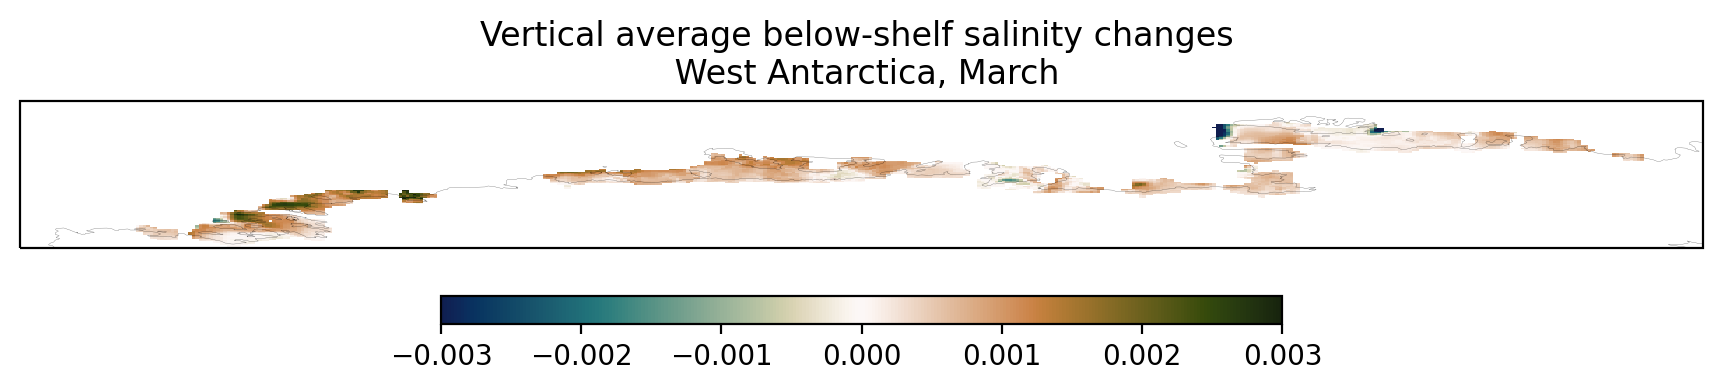

In [17]:
fig, axs = plt.subplots(dpi=200,
                        figsize=(8.5,5),
                        subplot_kw={'projection': ccrs.PlateCarree()},
                        layout='constrained',
                       )

axs.coastlines(linewidth=0.1, alpha=0.7)

WA_model2.weighted(weights=ds_S.drF).mean(dim='Z')[:,:,2].plot(transform=ccrs.PlateCarree(),
                                                               y='YC', 
                                                               #vmin=-0.005, vmax=0.005,
                                                               vmin=-0.003, vmax=0.003,
                                                               extend='neither',
                                                               #cmap=plt.get_cmap('RdBu_r'),
                                                               cmap=cmo.cm.tarn_r,
                                                               cbar_kwargs={'orientation':'horizontal',
                                                                            'shrink':0.5,
                                                                            'fraction':0.1,
                                                                            'aspect':30,
                                                                            #'pad':0.15,
                                                                           },
                                                              )
plt.title('Vertical average below-shelf salinity changes \n West Antarctica, March')
plt.xlim([-160, -80])
plt.ylim([-78,-71])

plt.savefig('/work/Katherine.Turner/BGOSE/figures/vertavg_m03_dS_WA_i041.png',
            format='png'
           )

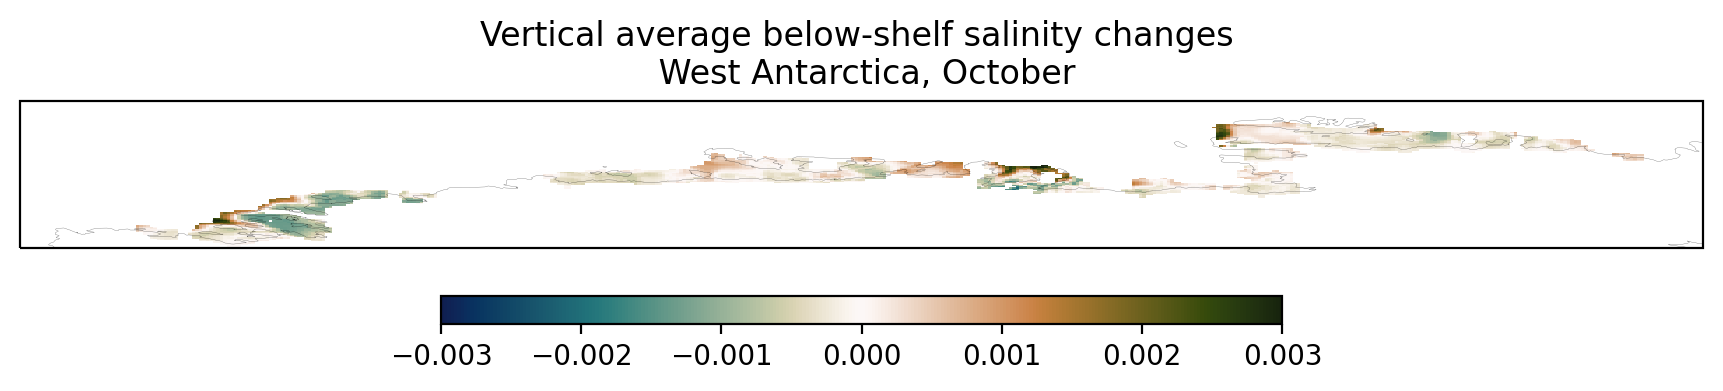

In [16]:
fig, axs = plt.subplots(dpi=200,
                        figsize=(8.5,5),
                        subplot_kw={'projection': ccrs.PlateCarree()},
                        layout='constrained',
                       )

axs.coastlines(linewidth=0.1, alpha=0.7)

WA_model2.weighted(weights=ds_S.drF).mean(dim='Z')[:,:,11].plot(transform=ccrs.PlateCarree(),
                                                                y='YC', 
                                                                #vmin=-0.005, vmax=0.005,
                                                                vmin=-0.003, vmax=0.003,
                                                                extend='neither',
                                                                #cmap=plt.get_cmap('RdBu_r'),
                                                                cmap=cmo.cm.tarn_r,
                                                                cbar_kwargs={'orientation':'horizontal',
                                                                             'shrink':0.5,
                                                                             'fraction':0.1,
                                                                             'aspect':30,
                                                                             #'pad':0.15,
                                                                            },
                                                               )
plt.title('Vertical average below-shelf salinity changes \n West Antarctica, October')
plt.xlim([-160, -80])
plt.ylim([-78,-71])
    

plt.savefig('/work/Katherine.Turner/BGOSE/figures/vertavg_m10_dS_WA_i041.png',
            format='png'
           )

In [8]:
S_WA_detrended = ml.trend.linear_detrend(Salt_WA[24:,:,:,:])
WA_model, resid = ml.trend.seasonal_model(S_WA_detrended, return_model=True)
WA_model2 = WA_model.groupby(WA_model.time.dt.month).mean()

S_EA_detrended = ml.trend.linear_detrend(Salt_EA[24:,:,:,:])
EA_model, resid = ml.trend.seasonal_model(S_EA_detrended, return_model=True)
EA_model2 = EA_model.groupby(EA_model.time.dt.month).mean()

S_RF_detrended = ml.trend.linear_detrend(Salt_RF[24:,:,:,:])
RF_model, resid = ml.trend.seasonal_model(S_RF_detrended, return_model=True)
RF_model2 = RF_model.groupby(RF_model.time.dt.month).mean()

/nbhome/Katherine.Turner/miniconda3/envs/py310/lib/python3.10/site-packages/xarray/core/accessor_dt.py:72: FutureWarning: Index.ravel returning ndarray is deprecated; in a future version this will return a view on self.
  values_as_series = pd.Series(values.ravel(), copy=False)
/nbhome/Katherine.Turner/miniconda3/envs/py310/lib/python3.10/site-packages/xarray/core/accessor_dt.py:72: FutureWarning: Index.ravel returning ndarray is deprecated; in a future version this will return a view on self.
  values_as_series = pd.Series(values.ravel(), copy=False)
/nbhome/Katherine.Turner/miniconda3/envs/py310/lib/python3.10/site-packages/xarray/core/accessor_dt.py:72: FutureWarning: Index.ravel returning ndarray is deprecated; in a future version this will return a view on self.
  values_as_series = pd.Series(values.ravel(), copy=False)
/nbhome/Katherine.Turner/miniconda3/envs/py310/lib/python3.10/site-packages/xarray/core/accessor_dt.py:72: FutureWarning: Index.ravel returning ndarray is deprecat

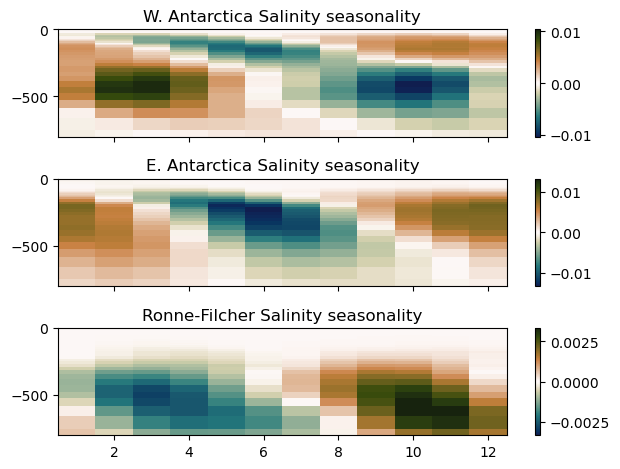

In [10]:
regions = ['W. Antarctica', 'E. Antarctica', 'Ronne-Filcher']

figs, axs = plt.subplots(nrows=3, ncols=1, sharex=True)

WA_model2.weighted(ds_S.rA).mean(dim=["YC", "XC"]).plot(ax=axs[0], cmap=cmo.cm.tarn_r)
EA_model2.weighted(ds_S.rA).mean(dim=["YC", "XC"]).plot(ax=axs[1], cmap=cmo.cm.tarn_r)
RF_model2.weighted(ds_S.rA).mean(dim=["YC", "XC"]).plot(ax=axs[2], cmap=cmo.cm.tarn_r)

for i in range(3):
    axs[i].set_ylim([-800, 0])
    axs[i].set_title(regions[i] + ' Salinity seasonality')
    axs[i].set_ylabel('')
    axs[i].set_xlabel('')
    
plt.tight_layout()

plt.savefig('/work/Katherine.Turner/BGOSE/figures/subsurface_seasonal_cycle_S_i041.png',
            dpi=100,
            format='png'
           )

# Looking at under shelf cross-sections
## Part 1 - Amery 

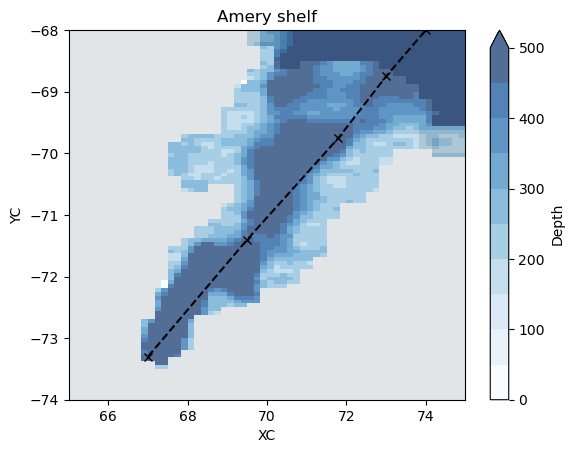

In [35]:
Names.index('Amery')

(ds_ice_id.shelf_mask == 48).plot(cmap='binary_r', alpha=0.3, add_colorbar= False)
ds_T.Depth.plot(alpha=0.7, cmap=plt.get_cmap('Blues', 10), vmin=0, vmax=500)

plt.plot([67, 69.5, 71.8, 73, 74], [-73.3, -71.4, -69.75, -68.75, -68], 'kx', linestyle='--')


plt.xlim([65, 75])
plt.ylim([-74, -68])

plt.title('Amery shelf')

plt.savefig('/work/Katherine.Turner/BGOSE/figures/Amery_shelf_map.png', format='png')

In [ ]:
def get_transect(ds, input_lons, input_lats):
    lon_2d, lat_2d = xr.broadcast(ds_T.XC, ds_T.YC)

    i_c,j_c,lats_c,lons_c = sectionate.create_section_composite(
        lon_2d,
        lat_2d,
        input_lons,
        input_lats,
    )
    
    x_idx = xr.DataArray(j_c, dims="transect_point")
    y_idx = xr.DataArray(i_c, dims="transect_point")
    
    ds_transect = ds.isel(YC=y_idx, XC=x_idx)
    
    return ds_transect

def get_seasonal_model(ds, time_start_idx=24):
    

In [49]:
Amery_lons=[67, 69.5, 71.8, 73, 74]
Amery_lats=[-73.3, -71.4, -69.75, -68.75, -68]

lon_2d, lat_2d = xr.broadcast(ds_T.XC, ds_T.YC)

i_c,j_c,lats_c,lons_c = sectionate.create_section_composite(
    lon_2d,
    lat_2d,
    Amery_lons,
    Amery_lats,
)

x_idx = xr.DataArray(j_c, dims="transect_point")
y_idx = xr.DataArray(i_c, dims="transect_point")

# Extract the transect using vector (advanced) indexing
# This turns da(time, z, y, x) -> da_transect(time, z, transect_point)
T_transect = ds_T.THETA[24:,:,:,:].isel(YC=y_idx, XC=x_idx).load()
S_transect = ds_S.SALT[24:,:,:,:].isel(YC=y_idx, XC=x_idx).load()

T_transect = T_transect.where(T_transect != 0)
S_transect = S_transect.where(S_transect != 0)

T_detrended = ml.trend.linear_detrend(T_transect)
T_model, resid = ml.trend.seasonal_model(T_detrended, return_model=True)
T_model2 = T_model.groupby(T_model.time.dt.month).mean()

S_detrended = ml.trend.linear_detrend(S_transect)
S_model, resid = ml.trend.seasonal_model(S_detrended, return_model=True)
S_model2 = S_model.groupby(S_model.time.dt.month).mean()

T_varexp_seas = 1 - (T_detrended - T_model).var(dim='time')/T_detrended.var(dim='time')
S_varexp_seas = 1 - (S_detrended - S_model).var(dim='time')/S_detrended.var(dim='time')

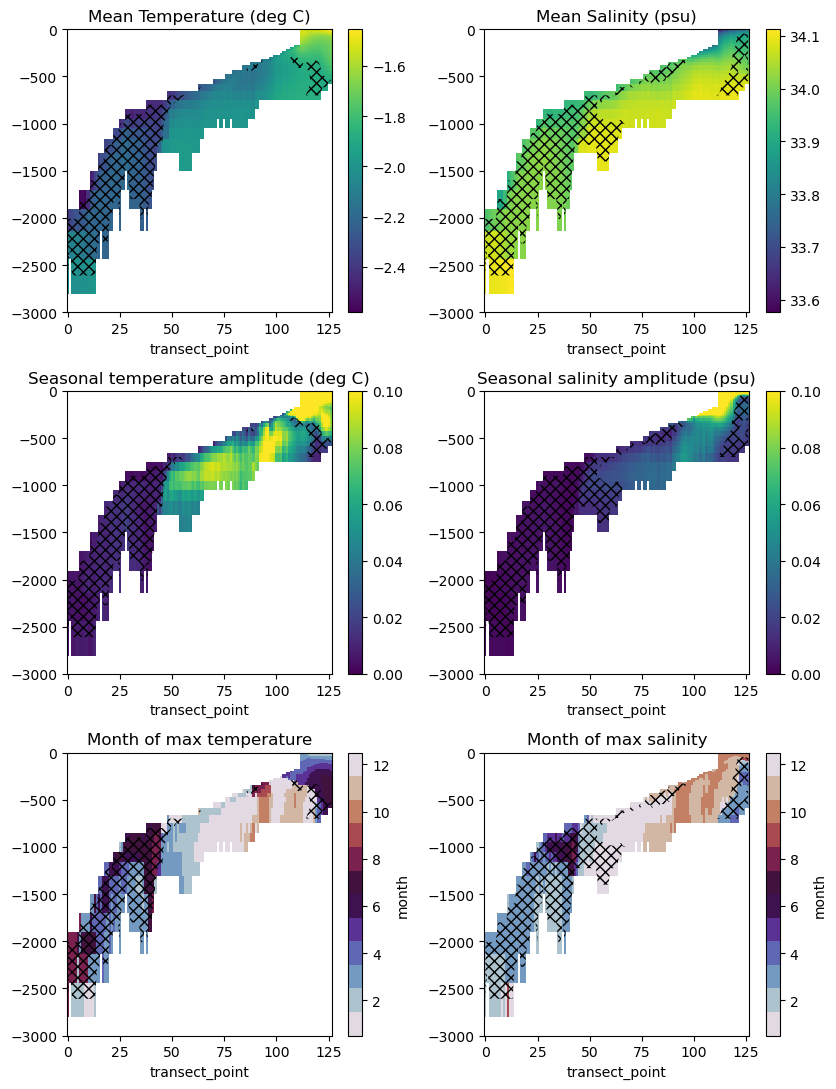

In [67]:
fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(8.5,11))
axs=axs.flatten()

T_transect.mean(dim='time').plot(ax=axs[0], cbar_kwargs={'label':''})
S_transect.mean(dim='time').plot(ax=axs[1], cbar_kwargs={'label':''})

T_model2.max(dim='month').plot(ax=axs[2], vmin=0, vmax=0.1, extend='neither')
S_model2.max(dim='month').plot(ax=axs[3], vmin=0, vmax=0.1, extend='neither')

T_model2.idxmax(dim='month').plot(ax=axs[4], vmin=0.5, vmax=12.5, cmap=plt.get_cmap('twilight',12))
S_model2.idxmax(dim='month').plot(ax=axs[5], vmin=0.5, vmax=12.5, cmap=plt.get_cmap('twilight',12))

for i in range(6):
    if i%2 == 0:
        T_varexp_seas.plot.contourf(ax=axs[i], levels=[0, 0.25, 1], colors='none', hatches=['xxx', ''], add_colorbar=False)
    else:
        S_varexp_seas.plot.contourf(ax=axs[i], levels=[0, 0.25, 1], colors='none', hatches=['xxx', ''], add_colorbar=False)
    axs[i].set_ylim([-3000, 0])
    axs[i].set_ylabel('')
    
axs[0].set_title('Mean Temperature (deg C)')
axs[1].set_title('Mean Salinity (psu)')
axs[2].set_title('Seasonal temperature amplitude (deg C)')
axs[3].set_title('Seasonal salinity amplitude (psu)')
axs[4].set_title('Month of max temperature')
axs[5].set_title('Month of max salinity')
    
plt.tight_layout()


plt.savefig('/work/Katherine.Turner/BGOSE/figures/Amery_cavity_seasonality.png', format='png')

## Part 2: Thwaites

In [169]:
Names.index('Thwaites')

18

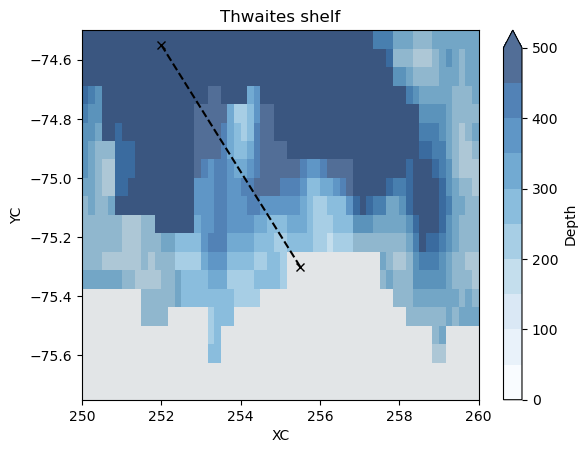

In [68]:
(ds_ice_id.shelf_mask == 18).plot(cmap='binary_r', alpha=0.3, add_colorbar= False)
ds_T.Depth.plot(alpha=0.7, cmap=plt.get_cmap('Blues', 10), vmin=0, vmax=500)

plt.plot([255.5,252], [-75.3, -74.55], 'kx', linestyle='--')

plt.xlim([250, 260])
plt.ylim([-75.75, -74.5])

plt.title('Thwaites shelf')

plt.savefig('/work/Katherine.Turner/BGOSE/figures/Thwaites_shelf_map.png', format='png')

In [69]:
Thwaites_lons=[255.5, 252]
Thwaites_lats=[-75.3, -74.55]

lon_2d, lat_2d = xr.broadcast(ds_T.XC, ds_T.YC)

i_c,j_c,lats_c,lons_c = sectionate.create_section_composite(
    lon_2d,
    lat_2d,
    Thwaites_lons,
    Thwaites_lats,
)

x_idx = xr.DataArray(j_c, dims="transect_point")
y_idx = xr.DataArray(i_c, dims="transect_point")

# 2. Extract the transect using vector (advanced) indexing
# This turns da(time, z, y, x) -> da_transect(time, z, transect_point)
T_transect = ds_T.THETA[24:,:,:,:].isel(YC=y_idx, XC=x_idx).load()
S_transect = ds_S.SALT[24:,:,:,:].isel(YC=y_idx, XC=x_idx).load()

T_transect = T_transect.where(T_transect != 0)
S_transect = S_transect.where(S_transect != 0)

T_detrended = ml.trend.linear_detrend(T_transect)
T_model, resid = ml.trend.seasonal_model(T_detrended, return_model=True)
T_model2 = T_model.groupby(T_model.time.dt.month).mean()

S_detrended = ml.trend.linear_detrend(S_transect)
S_model, resid = ml.trend.seasonal_model(S_detrended, return_model=True)
S_model2 = S_model.groupby(S_model.time.dt.month).mean()

T_varexp_seas = 1 - (T_detrended - T_model).var(dim='time')/T_detrended.var(dim='time')
S_varexp_seas = 1 - (S_detrended - S_model).var(dim='time')/S_detrended.var(dim='time')

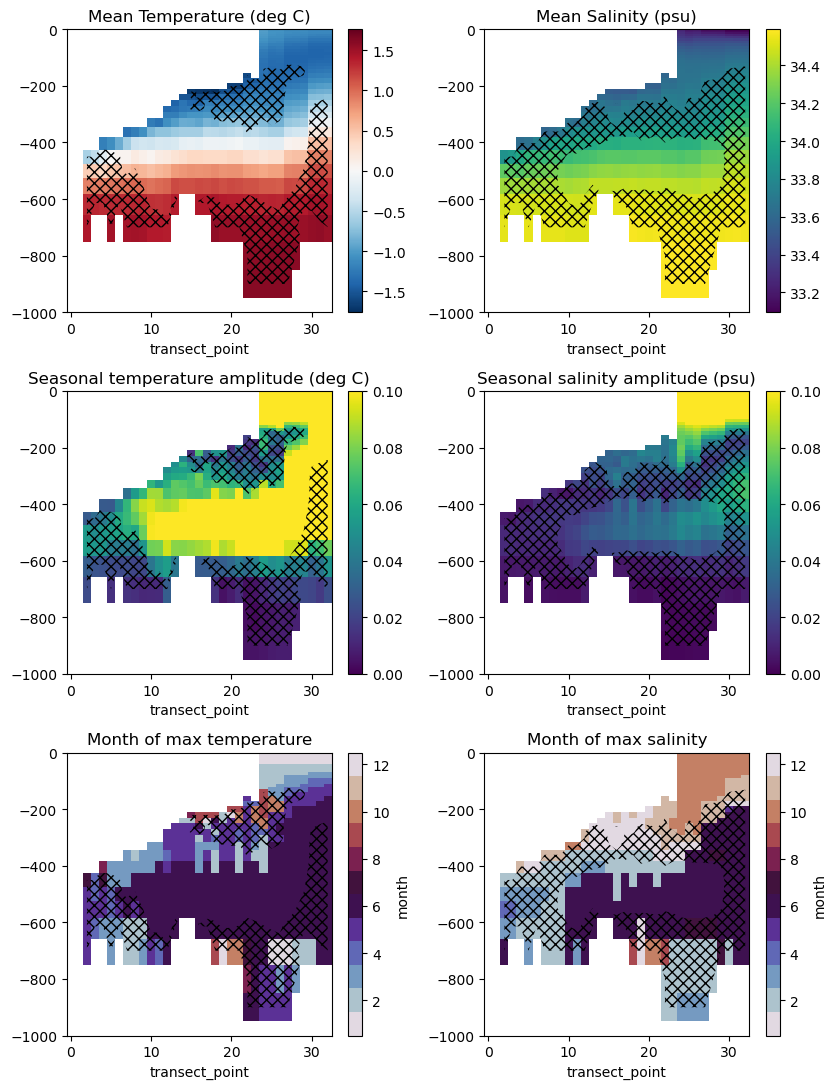

In [72]:
fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(8.5,11))
axs=axs.flatten()

T_transect.mean(dim='time').plot(ax=axs[0], cbar_kwargs={'label':''})
S_transect.mean(dim='time').plot(ax=axs[1], cbar_kwargs={'label':''})

T_model2.max(dim='month').plot(ax=axs[2], vmin=0, vmax=0.1, extend='neither')
S_model2.max(dim='month').plot(ax=axs[3], vmin=0, vmax=0.1, extend='neither')

T_model2.idxmax(dim='month').plot(ax=axs[4], vmin=0.5, vmax=12.5, cmap=plt.get_cmap('twilight',12))
S_model2.idxmax(dim='month').plot(ax=axs[5], vmin=0.5, vmax=12.5, cmap=plt.get_cmap('twilight',12))

for i in range(6):
    if i%2 == 0:
        T_varexp_seas.plot.contourf(ax=axs[i], levels=[0, 0.25, 1], colors='none', hatches=['xxx', ''], add_colorbar=False)
    else:
        S_varexp_seas.plot.contourf(ax=axs[i], levels=[0, 0.25, 1], colors='none', hatches=['xxx', ''], add_colorbar=False)
    axs[i].set_ylim([-1000, 0])
    axs[i].set_ylabel('')
    
axs[0].set_title('Mean Temperature (deg C)')
axs[1].set_title('Mean Salinity (psu)')
axs[2].set_title('Seasonal temperature amplitude (deg C)')
axs[3].set_title('Seasonal salinity amplitude (psu)')
axs[4].set_title('Month of max temperature')
axs[5].set_title('Month of max salinity')
    
plt.tight_layout()

plt.savefig('/work/Katherine.Turner/BGOSE/figures/Thwaites_cavity_seasonality.png', format='png')

## Totten Ice shelf

In [184]:
Names.index('Totten')

41

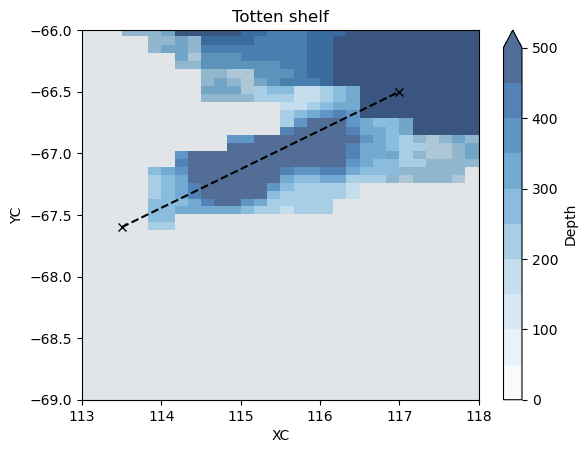

In [74]:
(ds_ice_id.shelf_mask == 41).plot(cmap='binary_r', alpha=0.3, add_colorbar= False)
ds_T.Depth.plot(alpha=0.7, cmap=plt.get_cmap('Blues', 10), vmin=0, vmax=500)

plt.plot([113.5,117], [-67.6, -66.5], 'kx', linestyle='--')

plt.xlim([113, 118])
plt.ylim([-69, -66])

plt.title('Totten shelf')

plt.savefig('/work/Katherine.Turner/BGOSE/figures/Totten_shelf_map.png', format='png')

In [75]:
Totten_lons=[113.5,117]
Totten_lats=[-67.6, -66.5]

lon_2d, lat_2d = xr.broadcast(ds_T.XC, ds_T.YC)

i_c,j_c,lats_c,lons_c = sectionate.create_section_composite(
    lon_2d,
    lat_2d,
    Totten_lons,
    Totten_lats,
)

x_idx = xr.DataArray(j_c, dims="transect_point")
y_idx = xr.DataArray(i_c, dims="transect_point")

# 2. Extract the transect using vector (advanced) indexing
# This turns da(time, z, y, x) -> da_transect(time, z, transect_point)
T_transect = ds_T.THETA[24:,:,:,:].isel(YC=y_idx, XC=x_idx).load()
S_transect = ds_S.SALT[24:,:,:,:].isel(YC=y_idx, XC=x_idx).load()

T_transect = T_transect.where(T_transect != 0)
S_transect = S_transect.where(S_transect != 0)

T_detrended = ml.trend.linear_detrend(T_transect)
T_model, resid = ml.trend.seasonal_model(T_detrended, return_model=True)
T_model2 = T_model.groupby(T_model.time.dt.month).mean()

S_detrended = ml.trend.linear_detrend(S_transect)
S_model, resid = ml.trend.seasonal_model(S_detrended, return_model=True)
S_model2 = S_model.groupby(S_model.time.dt.month).mean()

T_varexp_seas = 1 - (T_detrended - T_model).var(dim='time')/T_detrended.var(dim='time')
S_varexp_seas = 1 - (S_detrended - S_model).var(dim='time')/S_detrended.var(dim='time')

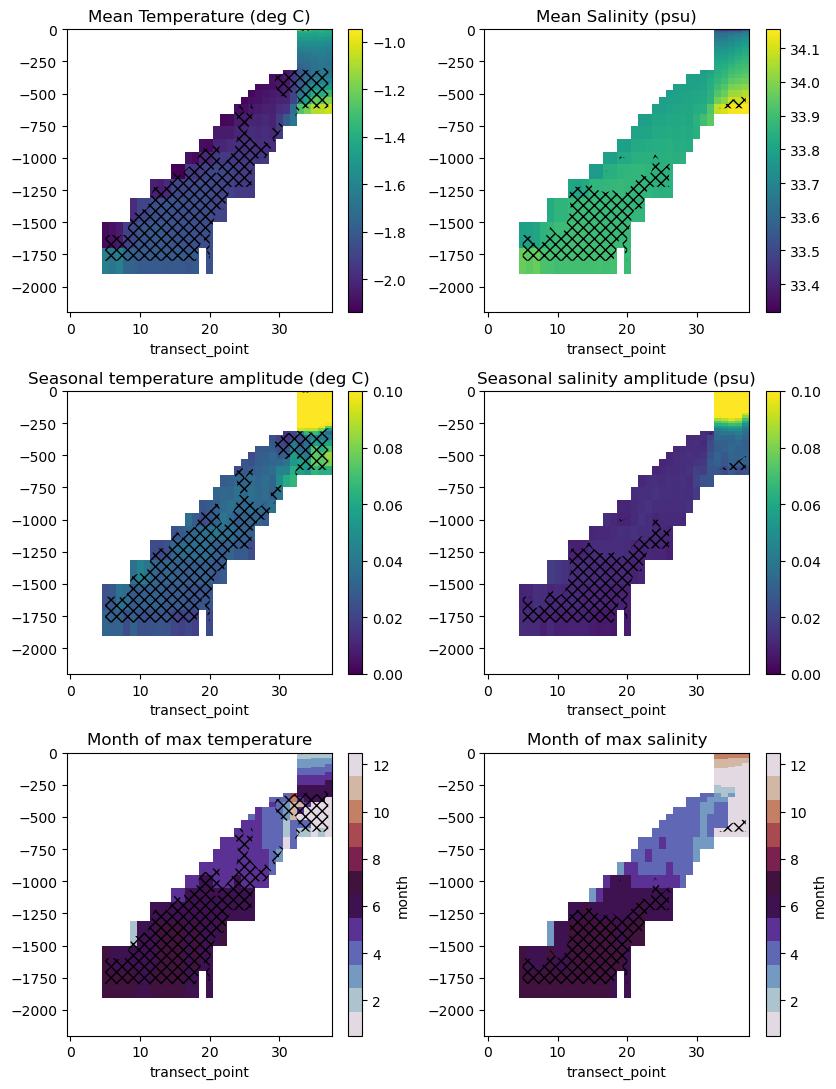

In [76]:
fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(8.5,11))
axs=axs.flatten()

T_transect.mean(dim='time').plot(ax=axs[0], cbar_kwargs={'label':''})
S_transect.mean(dim='time').plot(ax=axs[1], cbar_kwargs={'label':''})

T_model2.max(dim='month').plot(ax=axs[2], vmin=0, vmax=0.1, extend='neither')
S_model2.max(dim='month').plot(ax=axs[3], vmin=0, vmax=0.1, extend='neither')

T_model2.idxmax(dim='month').plot(ax=axs[4], vmin=0.5, vmax=12.5, cmap=plt.get_cmap('twilight',12))
S_model2.idxmax(dim='month').plot(ax=axs[5], vmin=0.5, vmax=12.5, cmap=plt.get_cmap('twilight',12))

for i in range(6):
    if i%2 == 0:
        T_varexp_seas.plot.contourf(ax=axs[i], levels=[0, 0.25, 1], colors='none', hatches=['xxx', ''], add_colorbar=False)
    else:
        S_varexp_seas.plot.contourf(ax=axs[i], levels=[0, 0.25, 1], colors='none', hatches=['xxx', ''], add_colorbar=False)
    axs[i].set_ylim([-2200, 0])
    axs[i].set_ylabel('')
    
axs[0].set_title('Mean Temperature (deg C)')
axs[1].set_title('Mean Salinity (psu)')
axs[2].set_title('Seasonal temperature amplitude (deg C)')
axs[3].set_title('Seasonal salinity amplitude (psu)')
axs[4].set_title('Month of max temperature')
axs[5].set_title('Month of max salinity')
    
plt.tight_layout()

plt.savefig('/work/Katherine.Turner/BGOSE/figures/Totten_cavity_seasonality.png', format='png')

# Connect to shelf melt seasonality

1:12 --> Antarctic Peninsula 

13:27 --> W Antarctica (no Ronne or Ross)

27:29  # Ross Sea

29:-1  # E Antarctica (no Filchner or Ross)

12, -1  # Ronne-Filchner

In [77]:
ds_SHI = xr.open_dataset('/work/Katherine.Turner/BGOSE/data_i041_glob/SHIfwFlx_bgoseI041_2013to2026_monthly.nc')

In [95]:
Amery_lons=[67, 69.5, 71.8, 73, 74]
Amery_lats=[-73.3, -71.4, -69.75, -68.75, -68]

Thwaites_lons=[255.5, 252]
Thwaites_lats=[-75.3, -74.55]

Totten_lons=[113.5,117]
Totten_lats=[-67.6, -66.5]

lon_2d, lat_2d = xr.broadcast(ds_SHI.XC, ds_SHI.YC)

m_per_year = -1 * 60**2 * 365 * 24 * 1e-3 

In [112]:
lons = Amery_lons
lats = Amery_lats

i_c,j_c,lats_c,lons_c = sectionate.create_section_composite(
    lon_2d,
    lat_2d,
    lons,
    lats,
)

x_idx = xr.DataArray(j_c, dims="transect_point")
y_idx = xr.DataArray(i_c, dims="transect_point")

# 2. Extract the transect using vector (advanced) indexing
# This turns da(time, z, y, x) -> da_transect(time, z, transect_point)
shelf_transect = ds_SHI.SHIfwFlx[24:,:,:].isel(YC=y_idx, XC=x_idx).load()

melt_detrended = ml.trend.linear_detrend(shelf_transect)
model, resid = ml.trend.seasonal_model(melt_detrended, return_model=True)
model2 = model.groupby(model.time.dt.month).mean()

melt_varexp =  1 - (melt_detrended - model).var(dim='time')/melt_detrended.var(dim='time')

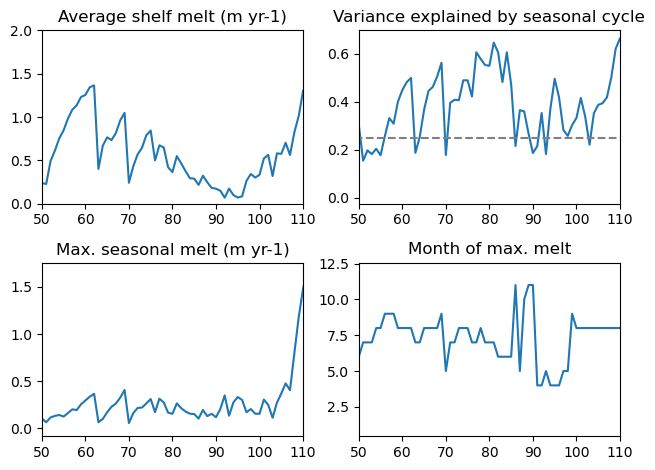

In [121]:
fig, axs = plt.subplots(nrows=2, ncols=2)
axs=axs.flatten()

(m_per_year * shelf_transect).mean(dim='time').plot(ax=axs[0])
axs[0].set_ylim([0, 2])
axs[0].set_title('Average shelf melt (m yr-1)')

melt_varexp.plot(ax=axs[1])
axs[1].plot([1, 110], [0.25, 0.25], color='grey', linestyle='--')
axs[1].set_title('Variance explained by seasonal cycle')


(m_per_year * model2).max(dim='month').plot(ax=axs[2])
axs[2].set_title('Max. seasonal melt (m yr-1)')

model2.idxmax(dim='month').plot(ax=axs[3])
axs[3].set_title('Month of max. melt')


for i in range(4):
    axs[i].set_xlim([50, 110])
    axs[i].set_ylabel('')
    axs[i].set_xlabel('')
    
plt.tight_layout()

plt.savefig('/work/Katherine.Turner/BGOSE/figures/Amery_shelf_transect_seasonality_v2.png',
               format='png')

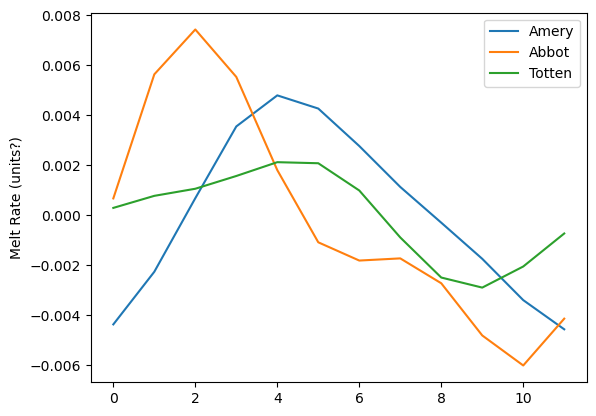

In [225]:
shelves = ['Amery', 'Abbot', 'Totten']

for i, shelf in enumerate(shelves):
    name_idx = Names.index(shelf)
    
    idx_shelf = ds_ice_id.shelf_mask == name_idx
    area_shelf = (idx_shelf * ds_SHI.rA).sum()
    
    total_melt = (idx_shelf * ds_SHI.SHIfwFlx[24:,:,:]).sum(dim=['XC', 'YC'])
    
    melt_detrended = ml.trend.linear_detrend(total_melt)
    model, resid = ml.trend.seasonal_model(melt_detrended, return_model=True)
    model2 = model.groupby(model.time.dt.month).mean()
    
    plt.plot(-1 * model2, label=f"{shelf}")

plt.ylabel('Melt Rate (units?)')
plt.legend()

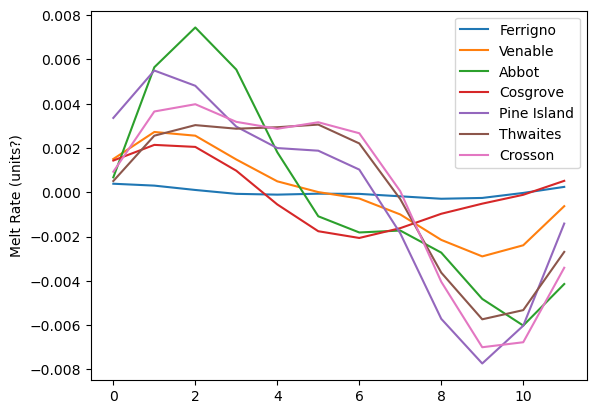

In [223]:
for i in range(13,20):
    #name_idx = Names.index(shelf)
    
    idx_shelf = ds_ice_id.shelf_mask == i
    area_shelf = (idx_shelf * ds_SHI.rA).sum()
    
    total_melt = (idx_shelf * ds_SHI.SHIfwFlx[24:,:,:]).sum(dim=['XC', 'YC'])
    
    melt_detrended = ml.trend.linear_detrend(total_melt)
    model, resid = ml.trend.seasonal_model(melt_detrended, return_model=True)
    model2 = model.groupby(model.time.dt.month).mean()
    
    plt.plot(-1 * model2, label=f"{Names[i]}")

plt.ylabel('Melt Rate (units?)')
plt.legend()

In [218]:
len(Names)

67